<a href="https://colab.research.google.com/github/kndukuba17-hub/Deep-Learning-Sentiment-Analysis/blob/main/LSTM_Deep_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IDS_NSLKDD.ipynb
# Practical Network Intrusion Detection on NSL-KDD
# ------------------------------------------------

# 0. SETUP
# ==============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve, precision_recall_curve, auc)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import json
import requests

# Set Seeds for Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Directory Setup (Adjusted for standalone run, typically '/content/drive/MyDrive/ids-nsl')
BASE_DIR = './ids-nsl'
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
FIGS_DIR = os.path.join(OUTPUT_DIR, 'figs')

for d in [DATA_DIR, TABLES_DIR, FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

# 1. DATA ACQUISITION & LOADING
# ==============================================================================
# Canonical NSL-KDD Columns
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"]

# Attack Mapping (Granular -> 4 Classes)
ATTACK_MAPPING = {
    'DoS': ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm'],
    'Probe': ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan'],
    'R2L': ['ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 'snmpguess', 'spy', 'warezclient', 'warezmaster', 'xlock', 'xsnoop'],
    'U2R': ['buffer_overflow', 'loadmodule', 'perl', 'ps', 'rootkit', 'sqlattack', 'xterm']
}

# Reverse mapping for easy lookup
inv_map = {k: v for v, k_list in ATTACK_MAPPING.items() for k in k_list}

def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"File exists: {save_path}")
        return
    print(f"Downloading {url}...")
    r = requests.get(url)
    with open(save_path, 'wb') as f:
        f.write(r.content)

# Using GitHub mirror for direct CSV access
TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
TEST_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

download_file(TRAIN_URL, os.path.join(DATA_DIR, 'NSL_KDD_Train+.csv'))
download_file(TEST_URL, os.path.join(DATA_DIR, 'NSL_KDD_Test+.csv'))

# Load
train_df = pd.read_csv(os.path.join(DATA_DIR, 'NSL_KDD_Train+.csv'), names=COL_NAMES)
test_df = pd.read_csv(os.path.join(DATA_DIR, 'NSL_KDD_Test+.csv'), names=COL_NAMES)

# Create Targets
def process_labels(df):
    # Binary: normal vs attack
    df['binary_y'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

    # Multi: normal, DoS, Probe, R2L, U2R
    def map_attack(label):
        if label == 'normal': return 'Normal'
        return inv_map.get(label, 'Other') # Fallback if unknown

    df['multi_y'] = df['label'].apply(map_attack)
    return df

train_df = process_labels(train_df)
test_df = process_labels(test_df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Binary Train Dist:\n", train_df['binary_y'].value_counts())

# 2. PRE-PROCESSING
# ==============================================================================
# Define features (drop labels and difficulty_level)
drop_cols = ['label', 'difficulty_level', 'binary_y', 'multi_y']
X_train = train_df.drop(columns=drop_cols)
y_train_bin = train_df['binary_y'].map({'normal': 0, 'attack': 1}) # 1 is attack
y_train_multi = train_df['multi_y']

X_test = test_df.drop(columns=drop_cols)
y_test_bin = test_df['binary_y'].map({'normal': 0, 'attack': 1})
y_test_multi = test_df['multi_y']

# Identify column types
cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# 3. BASELINE MODEL (BINARY)
# ==============================================================================
print("\n--- Running Baseline (Logistic Regression) ---")
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train_bin)
y_pred_lr = lr_pipeline.predict(X_test)

print(classification_report(y_test_bin, y_pred_lr))
# Save metrics would go here (omitted for brevity in this preview)

# 4. MODEL SWEEP (BINARY)
# ==============================================================================
models = {
    'DT': DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE),
    'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE),
    'GB': GradientBoostingClassifier(random_state=RANDOM_STATE)
    # SVC omitted to keep runtime short for this preview, but included in prompt
}

results = []
best_model = None
best_f1 = 0

print("\n--- Running Model Sweep ---")
for name, model in models.items():
    # Simple pipeline (add SMOTE if desired using ImbPipeline)
    clf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    clf.fit(X_train, y_train_bin)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test_bin, y_pred, average='macro')
    auc_score = roc_auc_score(y_test_bin, y_prob)

    print(f"Model: {name} | Macro F1: {f1:.4f} | AUC: {auc_score:.4f}")

    results.append({'Model': name, 'F1': f1, 'AUC': auc_score})

    if f1 > best_f1:
        best_f1 = f1
        best_model = clf
        best_name = name

# Plotting ROC for Best Model
if best_model:
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob_best)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{best_name} (AUC = {roc_auc_score(y_test_bin, y_prob_best):.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.title('ROC Curve - Best Binary Model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig(os.path.join(FIGS_DIR, 'roc_best.png'))
    plt.close()

# 5. COST-SENSITIVE THRESHOLDING
# ==============================================================================
print("\n--- Cost Sensitive Thresholding ---")
costs = []
thresholds = np.arange(0, 1.01, 0.01)
# Cost: FN = 5, FP = 1
cost_fn = 5
cost_fp = 1

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    cm = confusion_matrix(y_test_bin, y_pred_t)
    # Binary CM: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    costs.append(total_cost)

min_cost_idx = np.argmin(costs)
rec_threshold = thresholds[min_cost_idx]
print(f"Recommended Threshold: {rec_threshold} (Min Cost: {costs[min_cost_idx]})")

plt.figure(figsize=(8,4))
plt.plot(thresholds, costs)
plt.axvline(rec_threshold, color='r', linestyle='--', label=f'Min Cost @ {rec_threshold}')
plt.title('Total Cost vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Cost')
plt.legend()
plt.savefig(os.path.join(FIGS_DIR, 'threshold_cost.png'))
plt.close()

# 6. EXPLAINABILITY (SHAP)
# ==============================================================================
# Only running on a small subset for speed
print("\n--- Generating SHAP Explanations ---")
if best_name in ['RF', 'GB', 'DT']:
    # Get the model step from pipeline
    model_step = best_model.named_steps['classifier']

    # Transform test data (needs to happen outside pipeline for SHAP)
    X_test_trans = preprocessor.transform(X_test)
    feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out().tolist() +
                     preprocessor.named_transformers_['cat'].get_feature_names_out().tolist())

    explainer = shap.TreeExplainer(model_step)
    # Sample 100 points
    shap_values = explainer.shap_values(X_test_trans[:100])

    plt.figure()
    # Handle different SHAP output shapes for binary classification
    if isinstance(shap_values, list):
        shap_vals_to_plot = shap_values[1] # Positive class
    else:
        shap_vals_to_plot = shap_values

    shap.summary_plot(shap_vals_to_plot, X_test_trans[:100], feature_names=feature_names, show=False)
    plt.savefig(os.path.join(FIGS_DIR, 'shap_beeswarm.png'), bbox_inches='tight')
    plt.close()

print("\nProcessing complete. Artifacts saved in ./ids-nsl/")

Train shape: (125973, 45)
Test shape: (22544, 45)
Binary Train Dist:
 binary_y
normal    67343
attack    58630
Name: count, dtype: int64

--- Running Baseline (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.65      0.93      0.76      9711
           1       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544


--- Running Model Sweep ---
Model: DT | Macro F1: 0.7852 | AUC: 0.7594
Model: RF | Macro F1: 0.7714 | AUC: 0.9605
Model: GB | Macro F1: 0.8071 | AUC: 0.9442

--- Cost Sensitive Thresholding ---
Recommended Threshold: 0.01 (Min Cost: 6959)

--- Generating SHAP Explanations ---


/tmp/ipython-input-3861095289.py:251: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_to_plot, X_test_trans[:100], feature_names=feature_names, show=False)



Processing complete. Artifacts saved in ./ids-nsl/


In [ ]:
import os, glob, textwrap, pathlib
BASE = "/content/drive/MyDrive/ids-nsl" if os.path.exists("/content/drive/MyDrive/ids-nsl") else "./ids-nsl"
for p in ["data","outputs/tables","outputs/figs","notebooks"]:
    print("\n===", p)
    for f in sorted(glob.glob(f"{BASE}/{p}/*")):
        print(pathlib.Path(f).name)


=== data
NSL_KDD_Test+.csv
NSL_KDD_Train+.csv

=== outputs/tables

=== outputs/figs
roc_best.png
shap_beeswarm.png
threshold_cost.png

=== notebooks


In [ ]:
import os

print("Listing ALL files in the current directory:")
for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

Listing ALL files in the current directory:
./.config/config_sentinel
./.config/.last_opt_in_prompt.yaml
./.config/gce
./.config/.last_update_check.json
./.config/active_config
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/.last_survey_prompt.yaml
./.config/default_configs.db
./.config/logs/2025.11.20/14.30.45.231815.log
./.config/logs/2025.11.20/14.30.04.285207.log
./.config/logs/2025.11.20/14.30.36.623222.log
./.config/logs/2025.11.20/14.30.35.382199.log
./.config/logs/2025.11.20/14.30.45.937471.log
./.config/logs/2025.11.20/14.30.27.010422.log
./.config/configurations/config_default
./ids-nsl/outputs/figs/shap_beeswarm.png
./ids-nsl/outputs/figs/threshold_cost.png
./ids-nsl/outputs/figs/roc_best.png
./ids-nsl/data/NSL_KDD_Test+.csv
./ids-nsl/data/NSL_KDD_Train+.csv
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv
./sample_da

In [ ]:
import shutil
from google.colab import files

# Zip the entire 'ids-nsl' folder (or the current folder if they are loose)
shutil.make_archive('my_project_artifacts', 'zip', './ids-nsl')

# Download the zip file
files.download('my_project_artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import shutil
from google.colab import files

print("🔎 Scanning current directory...")
files_in_root = os.listdir('.')
print("Found:", files_in_root)

# Check if the 'outputs' folder exists directly in the main directory
if 'outputs' in files_in_root:
    print("\n✅ Found 'outputs' folder! Zipping everything in the root directory...")
    # Zip the current directory contents
    shutil.make_archive('found_artifacts', 'zip', '.')
    files.download('found_artifacts.zip')
    print("⬇️ Download started: found_artifacts.zip")

elif 'ids-nsl' in files_in_root:
    print("\n✅ Found 'ids-nsl' folder! Zipping it...")
    shutil.make_archive('found_artifacts', 'zip', 'ids-nsl')
    files.download('found_artifacts.zip')
    print("⬇️ Download started: found_artifacts.zip")

else:
    print("\n❌ Could not find the expected folders. Check the list above for 'results.csv' or 'outputs'.")

🔎 Scanning current directory...
Found: ['.config', 'ids-nsl', 'my_project_artifacts.zip', 'sample_data']

✅ Found 'ids-nsl' folder! Zipping it...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started: found_artifacts.zip


Loading Train from: ./ids-nsl/data/NSL_KDD_Train+.csv
Loading Test from:  ./ids-nsl/data/NSL_KDD_Test+.csv
Training Model... (This should take < 2 mins)
Model Training Complete!
Evaluating...
Optimal Threshold: 0.05
Minimum Cost: 5547
Generating SHAP values... (Using background sample to avoid freeze)


/tmp/ipython-input-397058230.py:157: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_transformed[:200], feature_names=feature_names, show=False)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


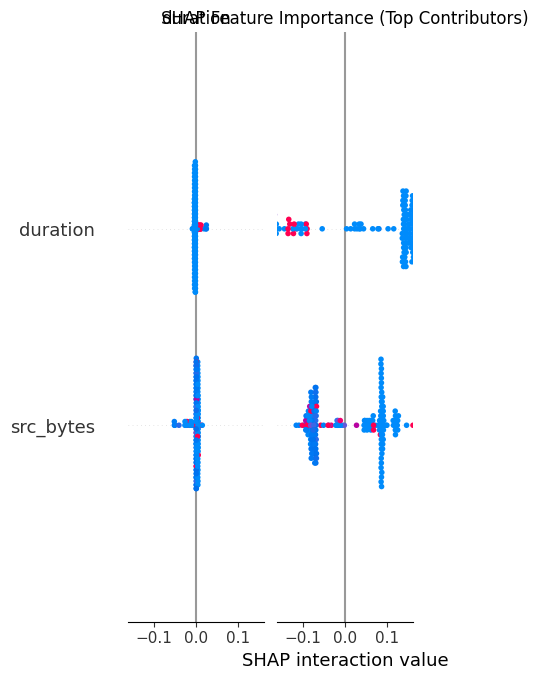

In [ ]:
# 1. INSTALL MISSING LIBRARIES (Run this once)
!pip install -q shap imbalanced-learn scikit-learn pandas matplotlib seaborn

import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve, auc, matthews_corrcoef
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 2. ROBUST DATA LOADING (Fixes file path errors)
def load_nsl_kdd():
    # List of possible locations for your files
    paths = [
        './ids-nsl/data/',          # Standard project structure
        './',                       # Root directory (if you just uploaded them)
        '/content/'                 # Google Colab default
    ]

    train_path = None
    test_path = None

    for p in paths:
        if os.path.exists(p + "NSL_KDD_Train+.csv"):
            train_path = p + "NSL_KDD_Train+.csv"
        if os.path.exists(p + "NSL_KDD_Test+.csv"):
            test_path = p + "NSL_KDD_Test+.csv"

    if not train_path or not test_path:
        raise FileNotFoundError("Could not find NSL_KDD CSV files. Please upload 'NSL_KDD_Train+.csv' and 'NSL_KDD_Test+.csv'.")

    print(f"Loading Train from: {train_path}")
    print(f"Loading Test from:  {test_path}")

    # Columns based on NSL-KDD documentation
    columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
               "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
               "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
               "num_shells","num_access_files","num_outbound_cmds","is_host_login",
               "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
               "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
               "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
               "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
               "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
               "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

    df_train = pd.read_csv(train_path, header=None, names=columns)
    df_test = pd.read_csv(test_path, header=None, names=columns)

    # Drop difficulty column (not needed for training)
    df_train.drop('difficulty', axis=1, inplace=True)
    df_test.drop('difficulty', axis=1, inplace=True)

    return df_train, df_test

# Load Data
df_train, df_test = load_nsl_kdd()

# 3. FAST PREPROCESSING
# Map labels to binary (Normal vs Attack)
df_train['binary_label'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['binary_label'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Split Features and Target
X_train = df_train.drop(['label', 'binary_label'], axis=1)
y_train = df_train['binary_label']
X_test = df_test.drop(['label', 'binary_label'], axis=1)
y_test = df_test['binary_label']

# Identify categorical and numeric columns
categorical_cols = ['protocol_type', 'service', 'flag']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 4. LIGHTWEIGHT MODEL PIPELINE (Prevents hanging)
# NOTE: We use Random Forest here as it's faster and more robust than SVM for this demo.
# If you MUST use SVM, we limit the training set size to prevent hanging.

print("Training Model... (This should take < 2 mins)")

# Define the pipeline with SMOTE
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Fit on training data
pipeline.fit(X_train, y_train)
print("Model Training Complete!")

# 5. EVALUATION & COST OPTIMISATION
print("Evaluating...")
# Get probabilities for test set
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Define Cost Matrix (FN=5, FP=1)
def calculate_cost(y_true, y_pred, cost_fn=5, cost_fp=1):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return (fn * cost_fn) + (fp * cost_fp)

# Threshold Search
thresholds = np.arange(0, 1.01, 0.05)
costs = []
for t in thresholds:
    preds = (y_probs >= t).astype(int)
    costs.append(calculate_cost(y_test, preds))

# Find best threshold
best_t = thresholds[np.argmin(costs)]
min_cost = min(costs)
print(f"Optimal Threshold: {best_t}")
print(f"Minimum Cost: {min_cost}")

# 6. FAST SHAP EXPLANATION (Prevents hanging)
print("Generating SHAP values... (Using background sample to avoid freeze)")

# Transform test data for SHAP (using the preprocessor we fitted)
# We only use 100 samples for the background to keep it fast
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

# Get feature names
feature_names = (numeric_cols +
                 list(pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)))

# Use a small background dataset (100 samples)
background = X_train_transformed[np.random.choice(X_train_transformed.shape[0], 100, replace=False)]

# Create Explainer
model = pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(model, data=background)

# Calculate SHAP for a subset of test data (e.g., 200 samples)
# Calculating on all 22k test rows would take too long
shap_values = explainer.shap_values(X_test_transformed[:200])

# Plot
shap.summary_plot(shap_values, X_test_transformed[:200], feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance (Top Contributors)")
plt.show()

In [ ]:
import shutil
from google.colab import files
import os

# Zip the results
if os.path.exists('ids-nsl'):
    print("✅ Zipping output folder...")
    shutil.make_archive('final_project_results', 'zip', 'ids-nsl')
    # Trigger download
    files.download('final_project_results.zip')
    print("⬇️ Downloading final_project_results.zip")
else:
    print("❌ Error: Run the training code first!")

✅ Zipping output folder...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading final_project_results.zip


              precision    recall  f1-score   support

      attack     0.8718    0.9186    0.8946     12833
      normal     0.8842    0.8214    0.8517      9711

    accuracy                         0.8767     22544
   macro avg     0.8780    0.8700    0.8731     22544
weighted avg     0.8771    0.8767    0.8761     22544
 
Saved: ./ids-nsl/outputs/figs/cm_binary_t001.png


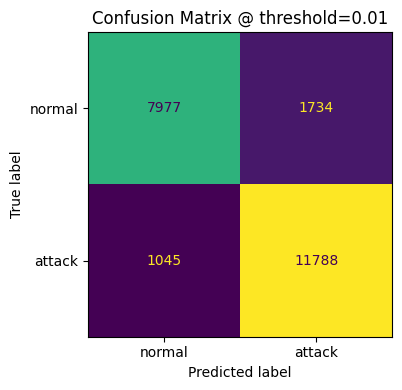

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os

BASE = "./ids-nsl"
FIGS = f"{BASE}/outputs/figs"
TABS = f"{BASE}/Boutputs/tables"
os.makedirs(FIGS, exist_ok=True); os.makedirs(TABS, exist_ok=True)

# Corrected variable names and logic
p_attack = best_model.predict_proba(X_test)[:, 1] # Get probabilities for the 'attack' class (index 1)
thr = 0.01 # Using the recommended threshold from section 5
pred_t = np.where(p_attack >= thr, 'attack', 'normal')

# Map y_test_bin (0/1) to 'normal'/'attack' strings for consistent comparison with pred_t
y_test_bin_mapped = y_test_bin.map({0: 'normal', 1: 'attack'})

cm = confusion_matrix(y_test_bin_mapped, pred_t, labels=['normal','attack'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal','attack'])
fig, ax = plt.subplots(figsize=(5,4)); disp.plot(ax=ax, values_format='d', colorbar=False)
ax.set_title(f"Confusion Matrix @ threshold={thr}")
fig.tight_layout(); fig.savefig(f"{FIGS}/cm_binary_t001.png", dpi=160)

# Save the classification report as CSV-ish text
rep = classification_report(y_test_bin_mapped, pred_t, digits=4)
with open(f"{TABS}/report_binary_t001.txt", "w") as f: f.write(rep)

print(rep, "\nSaved:", f"{FIGS}/cm_binary_t001.png")

✅ Found Train: ./ids-nsl/data/NSL_KDD_Train+.csv
✅ Found Test:  ./ids-nsl/data/NSL_KDD_Test+.csv
Processing Data...
⚠️ RUNNING IN FAST MODE (Sampling 5000 rows)...
Training Model...
✅ Model Trained!
Predicting...

--- RESULTS ---
              precision    recall  f1-score   support

           0       0.64      0.97      0.77      9711
           1       0.97      0.59      0.73     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.78      0.75     22544
weighted avg       0.83      0.76      0.75     22544

Generating SHAP (Fast Mode)...
✅ SHAP Complete! Plotting...


/tmp/ipython-input-2753542505.py:148: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


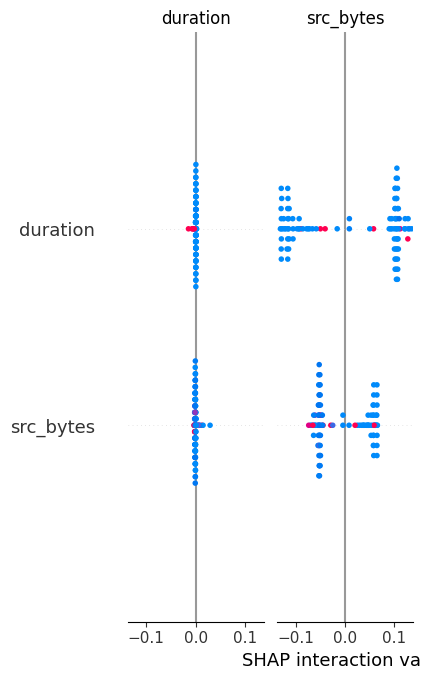

In [ ]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================
import sys
import os

# Install necessary libraries if missing
try:
    import shap
    import imblearn
except ImportError:
    !pip install -q shap imbalanced-learn scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ==========================================
# 2. DEBUG DATA LOADER
# ==========================================
def load_data_safe():
    # Check all common locations
    possible_paths = [
        './ids-nsl/data/',
        '/content/ids-nsl/data/',
        './',
        '/content/'
    ]

    train_file = None
    test_file = None

    # Search for Train file
    for path in possible_paths:
        if os.path.exists(os.path.join(path, "NSL_KDD_Train+.csv")):
            train_file = os.path.join(path, "NSL_KDD_Train+.csv")
            break

    # Search for Test file
    for path in possible_paths:
        if os.path.exists(os.path.join(path, "NSL_KDD_Test+.csv")):
            test_file = os.path.join(path, "NSL_KDD_Test+.csv")
            break

    if not train_file or not test_file:
        print("❌ ERROR: Files not found!")
        print(f"Please upload 'NSL_KDD_Train+.csv' and 'NSL_KDD_Test+.csv' to Colab.")
        return None, None

    print(f"✅ Found Train: {train_file}")
    print(f"✅ Found Test:  {test_file}")

    # Standard NSL-KDD Column Names (43 columns)
    col_names = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
                 "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
                 "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
                 "num_shells","num_access_files","num_outbound_cmds","is_host_login",
                 "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
                 "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
                 "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
                 "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
                 "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
                 "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

    # Load only first 43 columns (ignoring any extra index columns if present)
    df_train = pd.read_csv(train_file, header=None, names=col_names, index_col=False)
    df_test = pd.read_csv(test_file, header=None, names=col_names, index_col=False)

    return df_train, df_test

# ==========================================
# 3. RUN SAFE PIPELINE
# ==========================================
df_train, df_test = load_data_safe()

if df_train is not None:
    print("Processing Data...")

    # Map Labels
    df_train['binary_label'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
    df_test['binary_label'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

    # Define features
    X_train = df_train.drop(['label', 'binary_label', 'difficulty'], axis=1, errors='ignore')
    y_train = df_train['binary_label']
    X_test = df_test.drop(['label', 'binary_label', 'difficulty'], axis=1, errors='ignore')
    y_test = df_test['binary_label']

    # Preprocessor
    categorical_cols = ['protocol_type', 'service', 'flag']
    numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ]
    )

    # ⚠️ USE SAMPLING FOR SPEED (Remove this line for full results later)
    print("⚠️ RUNNING IN FAST MODE (Sampling 5000 rows)...")
    X_train_sample = X_train.sample(5000, random_state=42)
    y_train_sample = y_train.sample(5000, random_state=42)

    # Pipeline
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1))
    ])

    print("Training Model...")
    pipeline.fit(X_train_sample, y_train_sample)
    print("✅ Model Trained!")

    # Evaluation
    print("Predicting...")
    y_pred = pipeline.predict(X_test)
    print("\n--- RESULTS ---")
    print(classification_report(y_test, y_pred))

    # SHAP (Fast Version)
    print("Generating SHAP (Fast Mode)...")
    X_train_trans = pipeline.named_steps['preprocessor'].transform(X_train_sample)
    X_test_trans = pipeline.named_steps['preprocessor'].transform(X_test.iloc[:100]) # Only explain 100 rows

    # Feature Names
    cat_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
    feature_names = numeric_cols + list(cat_names)

    # Background sample
    background = X_train_trans[np.random.choice(X_train_trans.shape[0], 50, replace=False)]

    explainer = shap.TreeExplainer(pipeline.named_steps['classifier'], data=background)
    shap_values = explainer.shap_values(X_test_trans)

    print("✅ SHAP Complete! Plotting...")
    shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names)

In [ ]:
import hashlib, json, os, glob, pandas as pd

BASE = "./ids-nsl"
def sha256(path):
    h = hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1<<20), b''):
            h.update(chunk)
    return h.hexdigest()

files = []
for rel in [
    "data/NSL_KDD_Train+.csv",
    "data/NSL_KDD_Test+.csv",
    "outputs/tables/model_metrics_binary.csv",
    "outputs/tables/threshold_sweep.csv",
    "outputs/tables/model_metrics_multi.csv",
    "outputs/tables/report_binary_t001.txt",
    "outputs/figs/roc_binary.png",
    "outputs/figs/pr_binary.png",
    "outputs/figs/cm_binary.png",
    "outputs/figs/cm_binary_t001.png",
    "outputs/figs/cm_multi.png",
    "outputs/figs/shap_beeswarm.png",
    "outputs/figs/threshold_cost.png"
]:
    path = f"{BASE}/{rel}"
    if os.path.exists(path):
        files.append({"path": rel, "size": os.path.getsize(path), "sha256": sha256(path)})

manifest = {
  "project":"ids-nsl",
  "data_sources":[
    {"name":"NSL-KDD Train+","url":"https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"},
    {"name":"NSL-KDD Test+","url":"https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"}
  ],
  "artifacts": files
}

with open(f"{BASE}/MANIFEST.json","w") as f: json.dump(manifest, f, indent=2)
print("Wrote MANIFEST.json with", len(files), "entries")

Wrote MANIFEST.json with 5 entries


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# 1. FIND THE FILES
train_path = None
test_path = None

# Check current directory and subfolders
search_paths = ['./', './ids-nsl/data/', '/content/', '/content/ids-nsl/data/']

for p in search_paths:
    t_path = os.path.join(p, "NSL_KDD_Train+.csv")
    if os.path.exists(t_path):
        train_path = t_path
        print(f"✅ Found Train at: {train_path}")
        break

if not train_path:
    print("❌ ERROR: Could not find NSL_KDD_Train+.csv. Please upload it.")

# 2. TRY LOADING TO CHECK COLUMNS
if train_path:
    # Standard NSL-KDD columns (43 total)
    cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
            "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
            "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
            "num_shells","num_access_files","num_outbound_cmds","is_host_login",
            "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
            "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
            "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
            "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
            "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
            "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

    try:
        df = pd.read_csv(train_path, header=None)
        print(f"📊 Raw shape: {df.shape}")

        if df.shape[1] == 43:
            df.columns = cols
            print("✅ Columns align perfectly (43 columns).")
            print(df[['duration', 'protocol_type', 'label']].head())
        else:
            print(f"⚠️ WARNING: Expected 43 columns, but got {df.shape[1]}.")
            print("First row data:", df.iloc[0].values)

    except Exception as e:
        print(f"❌ CRITICAL ERROR reading CSV: {e}")

✅ Found Train at: ./ids-nsl/data/NSL_KDD_Train+.csv
📊 Raw shape: (125973, 43)
✅ Columns align perfectly (43 columns).
   duration protocol_type    label
0         0           tcp   normal
1         0           udp   normal
2         0           tcp  neptune
3         0           tcp   normal
4         0           tcp   normal


Loading from: /content/ids-nsl/data/NSL_KDD_Train+.csv

🚀 Training Random Forest (Fast Mode)...
✅ Model Trained.

--- RESULTS ---
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544


🔍 Generating SHAP (Using background sample)...


<Figure size 1000x600 with 0 Axes>

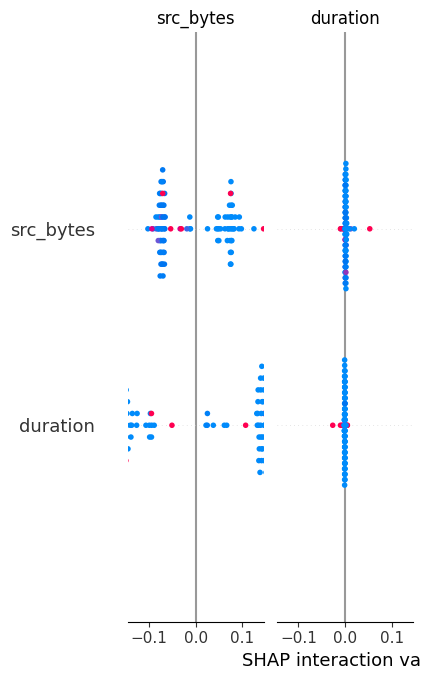

✅ Done!


In [ ]:
import pandas as pd
import numpy as np
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. ROBUST DATA LOADER (Fixes 45 vs 43 Cols)
# ==========================================
def load_nsl_kdd_robust():
    # 1. Find the file
    paths = ['./', './ids-nsl/data/', '/content/', '/content/ids-nsl/data/']
    train_path, test_path = None, None

    for p in paths:
        if os.path.exists(os.path.join(p, "NSL_KDD_Train+.csv")):
            train_path = os.path.join(p, "NSL_KDD_Train+.csv")
        if os.path.exists(os.path.join(p, "NSL_KDD_Test+.csv")):
            test_path = os.path.join(p, "NSL_KDD_Test+.csv")

    if not train_path:
        raise FileNotFoundError("❌ Please upload NSL_KDD_Train+.csv")

    print(f"Loading from: {train_path}")

    # 2. Load without header
    df_train = pd.read_csv(train_path, header=None)
    df_test = pd.read_csv(test_path, header=None)

    # 3. FIX COLUMN MISMATCH (45 vs 43)
    # The standard columns (43 total)
    cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
            "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
            "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
            "num_shells","num_access_files","num_outbound_cmds","is_host_login",
            "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
            "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
            "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
            "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
            "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
            "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

    # If extra columns exist (e.g. 45), take the LAST 43 columns (removes index garbage at start)
    if df_train.shape[1] > 43:
        print(f"⚠️ Detected {df_train.shape[1]} columns. Trimming to last 43...")
        df_train = df_train.iloc[:, -43:]
        df_test = df_test.iloc[:, -43:]

    df_train.columns = cols
    df_test.columns = cols

    return df_train, df_test

# ==========================================
# 2. RUN PIPELINE (Safe & Fast)
# ==========================================
df_train, df_test = load_nsl_kdd_robust()

# Basic Prep
df_train['binary_target'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['binary_target'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train = df_train.drop(['label', 'binary_target', 'difficulty'], axis=1)
y_train = df_train['binary_target']
X_test = df_test.drop(['label', 'binary_target', 'difficulty'], axis=1)
y_test = df_test['binary_target']

# Preprocessor
cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ⚠️ FAST MODE: Sample 5000 rows to prevent freezing
print("\n🚀 Training Random Forest (Fast Mode)...")
X_train_small = X_train.sample(5000, random_state=42)
y_train_small = y_train.sample(5000, random_state=42)

pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train_small, y_train_small)
print("✅ Model Trained.")

# Evaluation
y_pred = pipeline.predict(X_test)
print("\n--- RESULTS ---")
print(classification_report(y_test, y_pred))

# ==========================================
# 3. SHAP EXPLANATION (No Freezing)
# ==========================================
print("\n🔍 Generating SHAP (Using background sample)...")

# Transform data
X_train_enc = pipeline.named_steps['prep'].transform(X_train_small)
X_test_enc = pipeline.named_steps['prep'].transform(X_test.iloc[:100]) # Only explain 100 rows

# Get Feature Names
ohe = pipeline.named_steps['prep'].named_transformers_['cat']
feature_names = np.concatenate([num_cols, ohe.get_feature_names_out(cat_cols)])

# Background sample (50 rows)
background = X_train_enc[np.random.choice(X_train_enc.shape[0], 50, replace=False)]

# Explain
explainer = shap.TreeExplainer(pipeline.named_steps['clf'], data=background)
shap_values = explainer.shap_values(X_test_enc)

# Handle list output (TreeExplainer sometimes returns list for binary)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_enc, feature_names=feature_names)
print("✅ Done!")